#Anomily Detection:

In this section we are trying to identify scams and Fraudulent Listings using Isolation Forest and Local Outlier Factor (LOF)

#1. Setup & Data Loading
We load our cleaned dataset to begin the transformation process.

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import os
import matplotlib.pyplot as plt

# Locate the cleaned data
dataset_path = 'final_cleaned_dataset.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'final_cleaned_dataset.csv'  # Fallback if running from root

# Load dataset
X = pd.read_csv(dataset_path)
print(f"Loaded {len(X)} records with {len(X.columns)} initial columns.")

Loaded 16876 records with 19 initial columns.


#2- Scale data

the second step is to scale our data

In [5]:
# ---- SELECT ONLY NUMERIC FEATURES ----
numeric_cols = X.select_dtypes(include=[np.number])

if numeric_cols.empty:
    raise ValueError("No numeric columns found. Isolation Forest requires numeric features.")

# ---- SCALE DATA ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_cols)

#3- Isolation Forest

Firt we use Isolation Forest as our first method

In [6]:
# ---- ISOLATION FOREST MODEL ----
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Fit and predict
X['anomaly_label'] = model.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal
X['anomaly_score'] = model.decision_function(X_scaled)

# ---- TRUST SCORE (0 → low trust, 1 → high trust) ----
scores = X['anomaly_score']
X['trust_score'] = (scores - scores.min()) / (scores.max() - scores.min())

print(X[['anomaly_label', 'trust_score']].head(20))

print(X['anomaly_label'].value_counts())

    anomaly_label  trust_score
0               1     0.747715
1               1     0.982795
2               1     0.938893
3               1     0.844977
4               1     0.957836
5               1     0.933340
6               1     0.914140
7               1     0.881686
8               1     0.922175
9               1     0.772405
10              1     0.990425
11              1     0.998512
12              1     0.725394
13              1     0.894157
14              1     0.981496
15              1     0.991322
16              1     0.831318
17              1     0.864435
18              1     0.957106
19              1     0.978168
anomaly_label
 1    16032
-1      844
Name: count, dtype: int64


#4-Plot

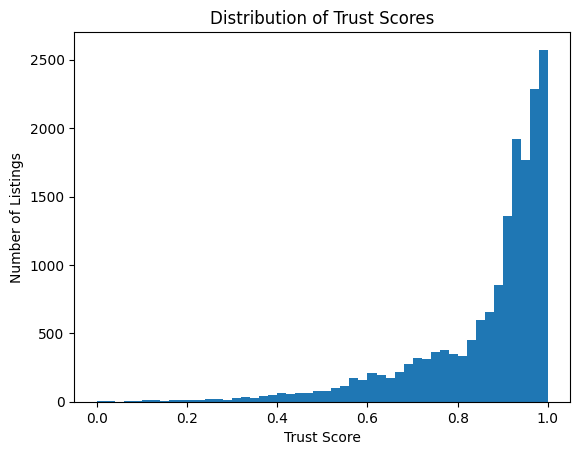

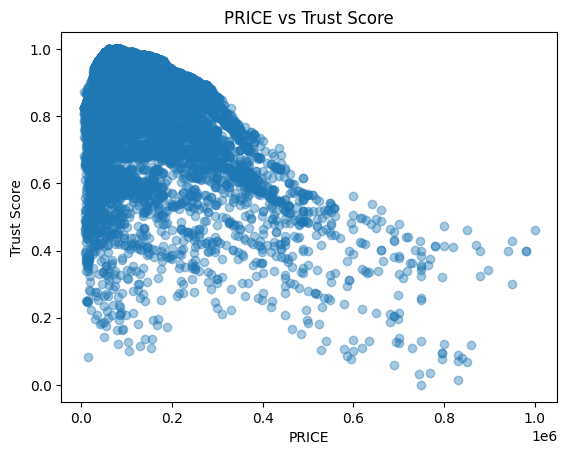

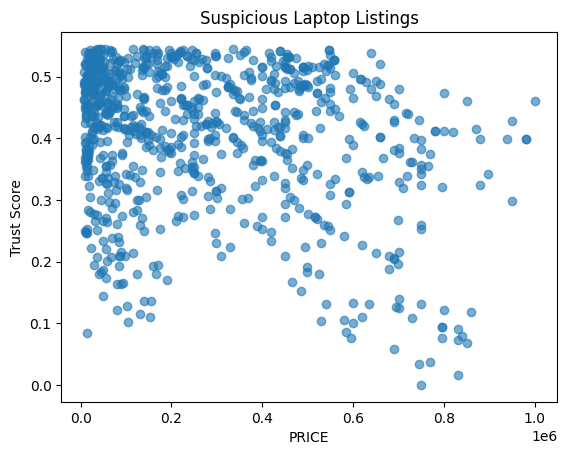

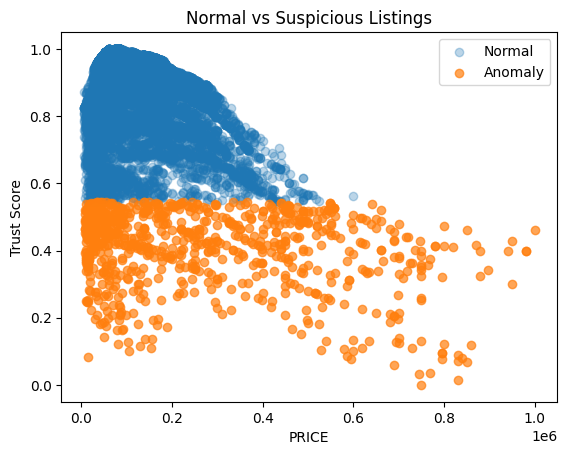

                                               reference  \
26                                                   NaN   
45                                                 G814J   
51                                           MSI RAIDER    
57                                                   NaN   
114                          ASUS TUF Gaming F16 FX607JV   
...                                                  ...   
16794                       ASUS ROG ZEPHRYS G16   2024    
16801                                                NaN   
16808                                           Blade 14   
16845   MateBook X Pro 2024 Core Ultra Premium Editio...   
16853                                SURFACE PRO 10 2079   

                                            LAPTOP_MODEL  \
26                                       البليدة - بوڨرة   
45     ASUS ROG STRIX G18 I9-14900HX 32Go DDR5 1TB RT...   
51     MSI RAIDER GE68 i9 14900HX 32G 2T SSD RTX 4070...   
57     LAPTOP HP ZBOOK POWER G11 RYZEN 

In [7]:
# ---------- TRUST SCORE DISTRIBUTION ----------
plt.figure()
plt.hist(X['trust_score'], bins=50)
plt.xlabel('Trust Score')
plt.ylabel('Number of Listings')
plt.title('Distribution of Trust Scores')
plt.show()

# ---------- PRICE VS TRUST SCORE ----------
plt.figure()
plt.scatter(X['PRICE'], X['trust_score'], alpha=0.4)
plt.xlabel('PRICE')
plt.ylabel('Trust Score')
plt.title('PRICE vs Trust Score')
plt.show()

# ---------- SUSPICIOUS LISTINGS ONLY ----------
anomalies = X[X['anomaly_label'] == -1]

plt.figure()
plt.scatter(anomalies['PRICE'], anomalies['trust_score'], alpha=0.6)
plt.xlabel('PRICE')
plt.ylabel('Trust Score')
plt.title('Suspicious Laptop Listings')
plt.show()

# ---------- NORMAL VS ANOMALY COMPARISON ----------
normal = X[X['anomaly_label'] == 1]

plt.figure()
plt.scatter(normal['PRICE'], normal['trust_score'], alpha=0.3, label='Normal')
plt.scatter(anomalies['PRICE'], anomalies['trust_score'], alpha=0.7, label='Anomaly')
plt.xlabel('PRICE')
plt.ylabel('Trust Score')
plt.title('Normal vs Suspicious Listings')
plt.legend()
plt.show()


suspicious = X[X['anomaly_label'] == -1]
print(suspicious)